# Milne's Problem

$$
   \mu\partial_\tau I +  I = \frac12\int_{-1}^I d\mu,~~-1<\mu<1,~~0<z<\tau_1
  $$

  $$
 I(0,\mu)|_{\mu>0}=c_s\delta(\mu-\mu_s),~I(\tau_1,\mu)|_{\mu<0} = 0.
$$

## First define the data set of the problem:

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Constants to define the problem

tau1 = 1.0              # Optical thickness of the atmosphere
mus = 1.0 / np.sqrt(3.0) # cosine of sunlight inclination
Is = 1.0                # Intensité de la lumière du soleil

# Constants to define the algorithm

Nz = 60                 # Number of layers in the atmosphere
dtau = tau1 / (Nz - 1)  # mesh size
Nmu = 100               # Number of angles in the quadrature (only use to display I)
kmax = 15               # number of iterations   




### The PDE is converted into an integral equation by the method of characteristics:

$$
J_0(z) := \frac12\int_{-1}^1 I d\mu = \frac{I_s}2 e^{-\frac{z}{\mu_s}}
	+  \frac{1}2\int_0^Z E_1( |z'-z|) J_0(z')d z'
$$

where $E_1$ is the first exponential integral.
ISIF computes $J_0$ for a given r.h.s., updates the r.h.s., recomputes $J_0$, etc

## Define helper functions

In [ ]:
def sqr(x):
    return x * x

def expint_E1(t=1.0):
    """Précision dans la fonction d'intégrale exponentielle E1"""
    t1 = abs(t) + 1.e-10 # for strictly positive argument
    Kexpint = int(9 + (t1 - 1) * 4) 
    gaNtaua = 0.577215664901533 # see wikipedia on exponential integral
    ak = t1
    soNtaue = -gaNtaua - math.log(t1) + ak
    for k in range(2, Kexpint):
        ak *= -t1 * (k - 1) / sqr(k)
        soNtaue += ak

    return soNtaue


def schwarzschild(tau):
    J00_val = Is / 2.0
    B = J00_val / tau1 / 2.0
    A = J00_val - B
    exp2tau = math.exp(-2.0 * tau)
    return 2.0 * (J00_val * exp2tau + A * (1.0 - exp2tau) - B * (2.0 * tau - 1.0 + exp2tau))

### 'schwarzschild' is for comparison. you may check that the precision of this approximation is poor

## Initialization of the ISIF

In [9]:
# global J0, S
 # Initialize arrays
J00 = [0.0] * Nz
J0 = [0.0] * Nz
S = [0.0] * Nz

for i in range(Nz):
    J0[i] = math.exp(-i * dtau / mus) * Is / 2.0

## The main loop

In [ ]:
print("k     J0[1]")
    
# Itérations sur la source (point fixe)
for k in range(kmax):
    for i in range(Nz):
        S[i] = J0[i]
            
    for i in range(Nz):
        J0[i] = math.exp(-i * dtau / mus) * Is / 2.0
        for j in range(1, Nz):
            J0[i] += dtau / 4.0 * expint_E1((j - i - 0.5) * dtau) * (S[j] + S[j - 1])
                
    print(f"{k} {J0[1]}")
        
print("\ntau      J0[tau]      Schwarzschild")
for i in range(Nz):
    print(f"{i * dtau:.5f} {J0[i]:.5f} {schwarzschild(i * dtau):.5f}")

### To display $z,\mu \to I(z,\mu)$ we use the formula given by method of characteristics in term of the sources in the Milne equation which has been computed above;  then python graphics are used.

Calcul de la surface I(tau, mu) en cours...


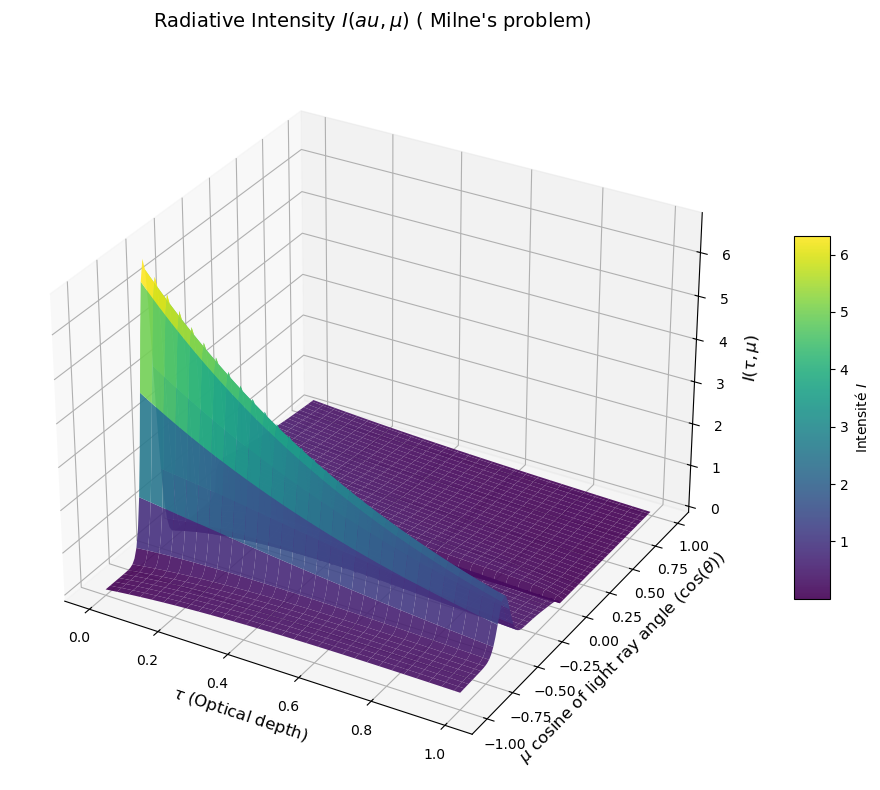

0

In [ ]:
 
def getI2():
    pi = 4.0 * math.atan(1.0)
    dmu = 2.0 / Nmu
    b = 1  # 1 pour Chandrasekhar, 0 pour Dirac
    lam = 12.0
    w = math.sqrt(pi) / 2.0 / lam * (math.erf(mus * lam) + math.erf((1.0 - mus) * lam))
    
    # Listes pour stocker les données du graphique
    mu_vals = []
    tau_vals = [j * dtau for j in range(Nz)]
    I_surface = []
    
    print("Calcul de la surface I(tau, mu) en cours...")
    
    mu = -1.0
    while mu <= 1.0:
        mu_vals.append(mu)
        I_row = []
        
        for j in range(Nz):
            Iss = int(mu < 0) * Is * math.exp(-sqr((mu + mus) * lam)) * math.exp(-j * dtau / mus) / w
            I = (1 - b) * Iss
            
            for i in range(Nz):
                condition = int(i < j) * int(mu < 0) + int(i > j) * int(mu > 0)
                if abs(mu) > 1e-9:  # Sécurité pour éviter la division par zéro
                    I += condition * dtau * math.exp(-abs((i - j) * dtau / abs(mu))) \
                         * (J0[i] + b * Is * math.exp(-i * dtau / mus) / 2.0) / abs(mu)
                         
            I_row.append(I + b * Iss)
            
        I_surface.append(I_row)
        mu += dmu

    # Conversion en tableaux NumPy pour la reconstruction de la surface
    Mu, Tau = np.meshgrid(mu_vals, tau_vals, indexing='ij')
    I_surface = np.array(I_surface)
    
    # --- Création du graphique 3D ---
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Tracé de la surface
    surf = ax.plot_surface(Tau, Mu, I_surface, cmap='viridis', edgecolor='none', alpha=0.9)
    
    # Personnalisation des axes
    ax.set_xlabel(r'$\tau$ (Optical depth)', fontsize=12)
    ax.set_ylabel(r'$\mu$ cosine of light ray angle ($\cos(\theta)$)', fontsize=12)
    ax.set_zlabel(r'$I(\tau, \mu)$', fontsize=12)
    ax.set_title("Radiative Intensity $I(\tau, \mu)$ ( Milne's problem)", fontsize=14, pad=20)
    
    # Ajout d'une barre de couleur
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Intensity $I$")
    
    # Orientation initiale de la vue 3D (ajustable à la souris)
    ax.view_init(elev=30, azim=-60)
    
    plt.tight_layout()
    plt.show()
    return 0

getI2() # Uncomment to display  I(tau,mu)
